In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("D:\ML&DL\Clustering_project\customer\data\Customers.csv")

In [4]:
data.rename(columns={
    "Annual Income (k$)": "Annual Income",
    "Spending Score (1-100)": "Spending Score"
            },
           inplace=True)

In [5]:
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data.isnull().sum()

CustomerID        0
Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64

In [7]:
data.dtypes

CustomerID         int64
Gender            object
Age                int64
Annual Income      int64
Spending Score     int64
dtype: object

In [8]:
data.Gender[data.Gender == "Male"] = 1
data.Gender[data.Gender == "Female"] = 0

In [9]:
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [10]:
data = data.astype("int64")

In [11]:
data_seg = data.drop(columns="CustomerID").copy()

In [12]:
data_seg.head()

,Gender,Age,Annual Income,Spending Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
data_seg = scaler.fit_transform(data_seg)

In [15]:
from sklearn.cluster import KMeans

In [16]:
wcss = [[],[]]
for n in range(2,15):
    model = KMeans(n_clusters=n)
    model.fit(data_seg)
    inertia = model.inertia_
    wcss[0].append(n)
    wcss[1].append(inertia)    

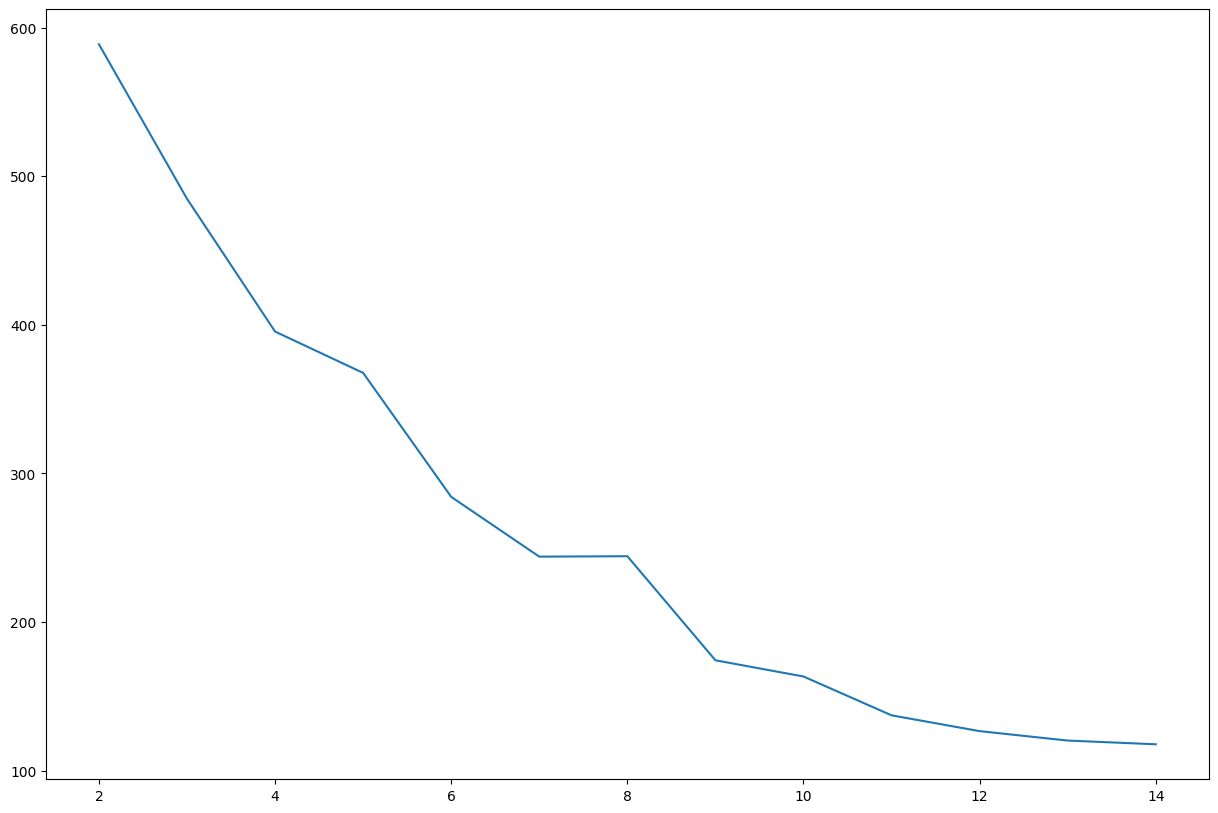

In [17]:
plt.figure(figsize=(15,10))
plt.plot(wcss[0],wcss[1])
plt.show()

In [19]:
from yellowbrick.cluster import KElbowVisualizer

In [20]:
model = KMeans()

,estimator,KMeans(n_clusters=14)
,ax,<Axes: >
,k,"(2, ...)"
,metric,'distortion'
,distance_metric,'euclidean'
,timings,True
,locate_elbow,True
,n_clusters,14
,init,'k-means++'
,n_init,'auto'
,max_iter,300


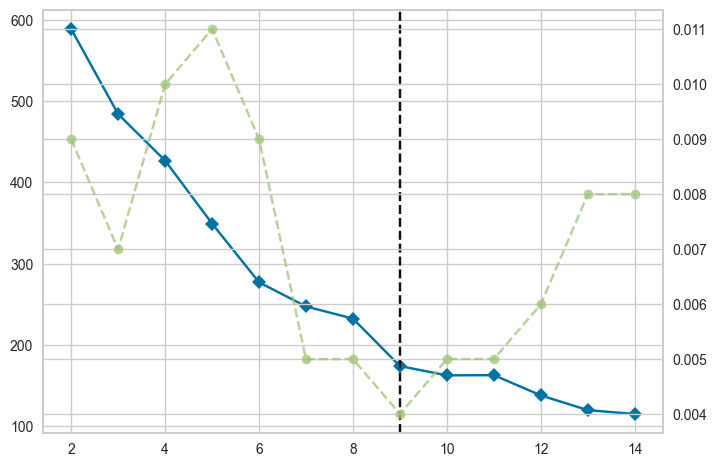

In [21]:
vis = KElbowVisualizer(model,k=(2,15))
vis.fit(data_seg)

In [22]:
model = KMeans(n_clusters=7)
model.fit(data_seg)

,n_clusters,7
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [23]:
data["Cluster"] = model.labels_

In [24]:
data

,CustomerID,Gender,Age,Annual Income,Spending Score,Cluster
0,1,1,19,15,39,5
1,2,1,21,15,81,5
2,3,0,20,16,6,1
3,4,0,23,16,77,1
4,5,0,31,17,40,1
...,...,...,...,...,...,...
195,196,0,35,120,79,4
196,197,0,45,126,28,2
197,198,1,32,126,74,4
198,199,1,32,137,18,3


In [25]:
describe = data.drop(columns="CustomerID").groupby("Cluster").describe()

In [26]:
describe[["Age","Spending Score"]]

Age                                                        \
        count       mean        std   min    25%   50%    75%   max   
Cluster                                                               
0        26.0  58.846154   8.048316  47.0  52.25  59.0  66.75  70.0   
1        48.0  27.270833   5.441134  18.0  23.00  27.5  31.00  40.0   
2        15.0  44.600000   7.660660  34.0  39.00  44.0  49.50  57.0   
3        19.0  38.473684  12.001706  19.0  32.50  40.0  46.50  59.0   
4        28.0  33.250000   3.874179  27.0  30.00  32.0  36.00  40.0   
5        25.0  25.720000   7.115242  18.0  19.00  24.0  31.00  40.0   
6        39.0  50.179487   9.264737  35.0  45.00  49.0  54.50  68.0   

        Spending Score                                                        
                 count       mean        std   min    25%   50%    75%   max  
Cluster                                                                       
0                 26.0  39.846154  17.721608   3.0  37.25  46.0  51.00  60.0  
1                 48.0  62.854167  19.997861   6.0  47.75  63.0  77.00  99.0  
2                 15.0  21.600000   9.701252   5.0  16.00  22.0  27.50  39.0  
3                 19.0  14.210526   9.801241   1.0   8.50  13.0  17.50  36.0  
4                 28.0  83.392857  10.045597  63.0  75.00  86.0  91.25  97.0  
5                 25.0  59.000000  18.227726  13.0  49.00  56.0  73.00  92.0  
6                 39.0  40.589744  15.018792   5.0  33.50  44.0  51.00  59.0

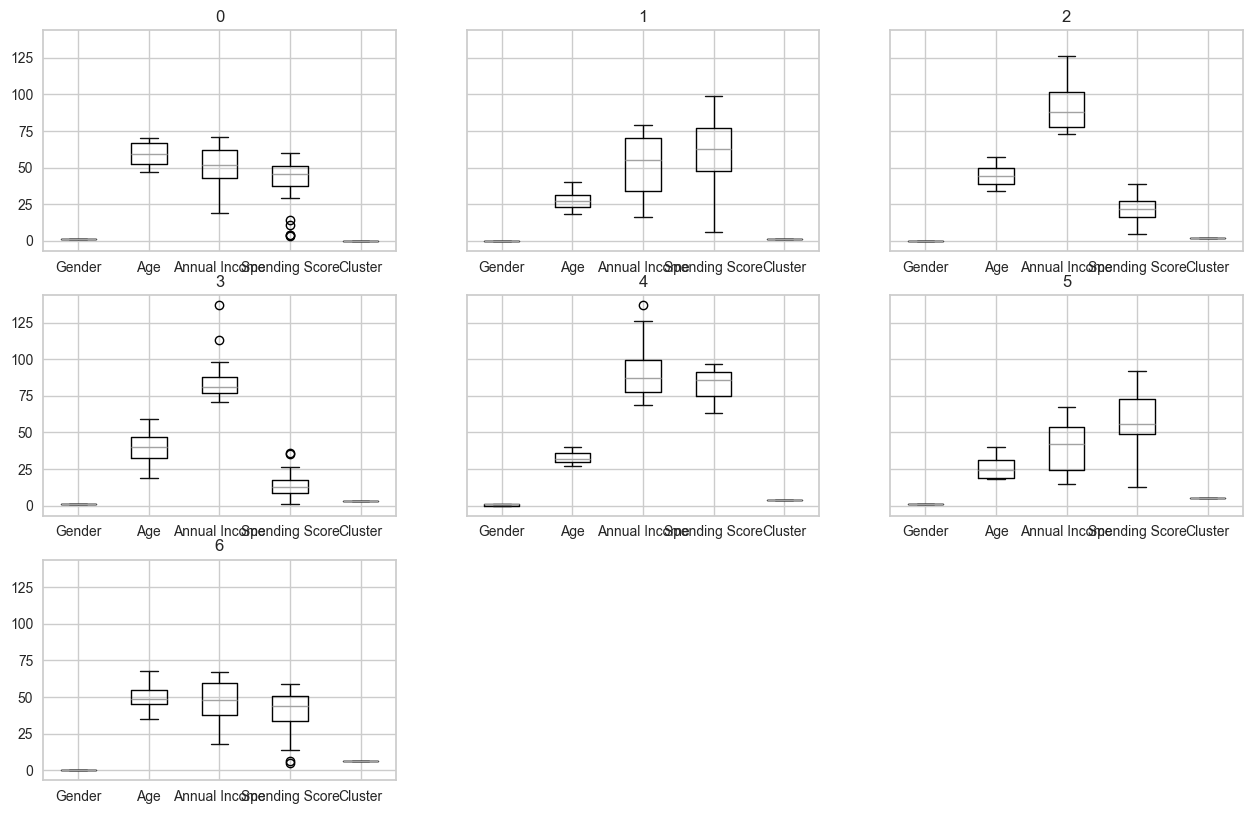

In [27]:
data.drop(columns="CustomerID").groupby("Cluster").boxplot(figsize = (15,10))
plt.show()